
# Notebook 1

**Diplomado, Módulo II: Técnicas Estadísticas**




## 1. ¿Qué es un espacio de probabilidad?

Cuando hacemos un experimento cuyo resultado no podemos predecir con certeza (lanzar una moneda, tirar un dado, medir cuánto tarda un cliente en ser atendido), decimos que es un **experimento aleatorio**.

Para poder "hacer matemáticas" con este tipo de experimentos, necesitamos tres ingredientes, que en conjunto forman un **espacio de probabilidad** $(\Omega, \mathcal{F}, \mathbb{P})$:

1. **$\Omega$ (espacio muestral):** el conjunto de todos los resultados posibles del experimento.
2. **$\mathcal{F}$ (eventos):** la colección de todos los subconjuntos de $\Omega$ a los que sí les podemos asignar una probabilidad (por ejemplo, "obtener un número par").
3. **$\mathbb{P}$ (probabilidad):** una función que le asigna a cada evento un número entre $0$ y $1$, que representa qué tan creíble o frecuente es ese resultado.

En palabras simples: $\Omega$ nos dice **qué puede pasar**, un evento nos dice **qué nos interesa que pase**, y $\mathbb{P}$ nos dice **qué tan probable es que pase**.



## 2. Espacio muestral $\Omega$

El **espacio muestral** es el conjunto de *todos* los resultados posibles de un experimento aleatorio.

**Ejemplos:**
- Lanzar una moneda: $\Omega = \{\text{águila}, \text{sol}\}$.
- Lanzar un dado: $\Omega = \{1,2,3,4,5,6\}$.
- Lanzar dos dados: $\Omega = \{(i,j) : i,j \in \{1,\dots,6\}\}$, y $|\Omega| = 36$.

En Python podemos construir estos espacios muestrales de forma explícita usando el módulo `itertools`, que nos permite generar todas las combinaciones posibles.


In [1]:
# Vamos a construir el espacio muestral de lanzar un dado dos veces (dos dados)
from itertools import product

Omega_dados = set(product([1, 2, 3, 4, 5, 6], repeat=2))

print("Número de resultados posibles (|Omega|):", len(Omega_dados))
print("Algunos resultados:", list(Omega_dados)[:5])


Número de resultados posibles (|Omega|): 36
Algunos resultados: [(3, 4), (4, 3), (3, 1), (5, 4), (4, 6)]



## 3. Eventos

Un **evento** es simplemente un subconjunto de $\Omega$, es decir, una colección de resultados que nos interesa observar.

**Ejemplo.** En el experimento de lanzar dos dados, el evento

$$A = \{(i,j) \in \Omega : i+j = 7\}$$

representa "la suma de los dos dados es 7".


In [2]:
# Definimos el evento A: la suma de los dos dados es igual a 7
A = {(i, j) for (i, j) in Omega_dados if i + j == 7}

print("El evento A (suma = 7) contiene los resultados:")
print(A)
print("Número de resultados favorables:", len(A))


El evento A (suma = 7) contiene los resultados:
{(3, 4), (4, 3), (6, 1), (1, 6), (2, 5), (5, 2)}
Número de resultados favorables: 6



## 4. Axiomas de Kolmogorov

Para que una función $\mathbb{P}$ definida sobre los eventos merezca llamarse "probabilidad", debe cumplir tres reglas básicas, propuestas por el matemático ruso Andréi Kolmogorov en 1933:

1. **No negatividad:** $\mathbb{P}(A) \geq 0$ para cualquier evento $A$.
2. **Normalización:** $\mathbb{P}(\Omega) = 1$ (algo del espacio muestral *siempre* ocurre).
3. **Aditividad numerable:** si $A_1, A_2, A_3, \dots$ son eventos mutuamente excluyentes (no pueden ocurrir al mismo tiempo, es decir $A_i \cap A_j = \emptyset$ para $i\neq j$), entonces
$$\mathbb{P}\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty}\mathbb{P}(A_i).$$

**De estos tres axiomas se pueden deducir varias propiedades útiles**, por ejemplo:
- $\mathbb{P}(\emptyset) = 0$ (el evento imposible tiene probabilidad cero).
- $\mathbb{P}(A^c) = 1 - \mathbb{P}(A)$ (probabilidad del complemento).
- Si $A \subseteq B$, entonces $\mathbb{P}(A) \leq \mathbb{P}(B)$ (monotonía).
- $\mathbb{P}(A \cup B) = \mathbb{P}(A) + \mathbb{P}(B) - \mathbb{P}(A \cap B)$.

Vamos a comprobar numéricamente, con nuestro ejemplo de los dos dados, que $\mathbb{P}(A) + \mathbb{P}(A^c) = 1$.


In [3]:
from fractions import Fraction

# Definimos la función de probabilidad Laplaciana P(E) = |E| / |Omega|
def P(E, Omega=Omega_dados):
    return Fraction(len(E), len(Omega))

# Evento A: la suma es 7. Evento A^c: la suma NO es 7 (el complemento)
A_c = Omega_dados - A

prob_A = P(A)
prob_Ac = P(A_c)

print("P(A) =", prob_A)
print("P(A^c) =", prob_Ac)
print("P(A) + P(A^c) =", prob_A + prob_Ac, " (debe dar 1, como dice el axioma 2)")


P(A) = 1/6
P(A^c) = 5/6
P(A) + P(A^c) = 1  (debe dar 1, como dice el axioma 2)



## 5. Probabilidad condicional

La **probabilidad condicional** de un evento $A$, dado que *ya sabemos* que ocurrió un evento $B$, se define como:

$$\mathbb{P}(A \mid B) = \frac{\mathbb{P}(A \cap B)}{\mathbb{P}(B)}, \qquad \text{siempre que } \mathbb{P}(B) > 0.$$

La idea es que, al saber que $B$ ya ocurrió, "reducimos" nuestro espacio muestral a $B$, y preguntamos qué proporción de $B$ también cumple $A$.

**Ejemplo.** Lanzamos dos dados. Sea:
- $A$: el primer dado muestra un número par.
- $B$: la suma de los dos dados es 7.

Vamos a calcular $\mathbb{P}(A \mid B)$: si ya sabemos que la suma dio 7, ¿qué tan probable es que el primer dado haya sido par?


In [4]:
# Evento A: el primer dado es par
A_par = {(i, j) for (i, j) in Omega_dados if i % 2 == 0}

# Evento B: la suma es 7 (ya lo habíamos definido arriba como "A", lo reetiquetamos)
B_suma7 = A

# Definimos la probabilidad condicional P(E | F) = |E∩F| / |F|
def prob_condicional(E, F):
    return Fraction(len(E & F), len(F))

prob_A_dado_B = prob_condicional(A_par, B_suma7)

print("P(primer dado par | suma = 7) =", prob_A_dado_B)
print("Es decir, si la suma dio 7, hay una probabilidad de", float(prob_A_dado_B),
      "de que el primer dado haya sido par.")


P(primer dado par | suma = 7) = 1/2
Es decir, si la suma dio 7, hay una probabilidad de 0.5 de que el primer dado haya sido par.



## 6. Independencia de eventos

Decimos que dos eventos $A$ y $B$ son **independientes** si el hecho de saber que ocurrió uno de ellos **no cambia** la probabilidad del otro. Formalmente:

$$\mathbb{P}(A \cap B) = \mathbb{P}(A)\cdot \mathbb{P}(B).$$

Esto es equivalente a decir que $\mathbb{P}(A\mid B) = \mathbb{P}(A)$ (si $\mathbb{P}(B)>0$).

**Ejemplo (un resultado que no es tan obvio).** Volvamos a lanzar dos dados. Sea:
- $A$: el primer dado es par.
- $B$: la suma de los dos dados es 7.

Intuitivamente podríamos pensar que "saber la suma" nos dice algo sobre el primer dado, pero vamos a comprobar con Python si en realidad $A$ y $B$ son independientes.


In [5]:
# Función que verifica si dos eventos son independientes: P(A∩B) = P(A)*P(B)
def son_independientes(E, F, Omega=Omega_dados):
    p_E = P(E, Omega)
    p_F = P(F, Omega)
    p_EF = P(E & F, Omega)
    return p_EF == p_E * p_F, p_EF, p_E * p_F

es_indep, p_interseccion, producto = son_independientes(A_par, B_suma7)

print("P(A ∩ B) =", p_interseccion)
print("P(A) * P(B) =", producto)
print("¿Son independientes A y B?", es_indep)


P(A ∩ B) = 1/12
P(A) * P(B) = 1/12
¿Son independientes A y B? True



Y sí, salió que $A$ (primer dado par) y $B$ (suma = 7) son independientes, cosa que la primera vez que lo vi me pareció rara. Pero si lo pensamos tantito tiene sentido: para que la suma dé 7 hay exactamente un valor del segundo dado que "arregla" cualquier valor del primero (si el primero es 1 el segundo tiene que ser 6, si el primero es 2 el segundo tiene que ser 5, y así). Entonces saber que la suma fue 7 no me dice nada nuevo sobre si el primer dado cayó par o impar.



## 7. Enfoque clásico (Laplaciano): ejemplo del volado

El **enfoque clásico** (o Laplaciano) de la probabilidad dice que, si un experimento tiene $|\Omega|$ resultados **igualmente posibles**, entonces la probabilidad de un evento $A$ es simplemente:

$$\mathbb{P}(A) = \frac{|A|}{|\Omega|} = \frac{\text{número de casos favorables}}{\text{número de casos totales}}.$$

Este enfoque es el más antiguo (por eso se llama clásico) y funciona muy bien cuando los resultados son simétricos, como en un volado con una moneda equilibrada o en un dado justo.

**Ejemplo (el volado).** Lanzamos una moneda 3 veces de forma independiente. El espacio muestral es
$$\Omega = \{A,S\}\times\{A,S\}\times\{A,S\}, \qquad |\Omega| = 2^3 = 8,$$
donde $A$="águila" y $S$="sol". Vamos a calcular la probabilidad de los eventos:
- $E_1$: todos los resultados son águila.
- $E_2$: todos los resultados son sol.
- $E_3$: por lo menos un resultado es sol.


In [6]:
from itertools import product
from fractions import Fraction

# Construimos el espacio muestral: 3 volados, cada uno "A" (águila) o "S" (sol)
Omega_volado = set(product(['A', 'S'], repeat=3))
print("Espacio muestral (3 volados):", Omega_volado)
print("|Omega| =", len(Omega_volado))

# Definimos los eventos de interés
E1_todas_aguila = {om for om in Omega_volado if om.count('A') == 3}
E2_todas_sol = {om for om in Omega_volado if om.count('S') == 3}
E3_al_menos_un_sol = {om for om in Omega_volado if om.count('S') >= 1}

# Usamos la probabilidad Laplaciana: P(E) = |E| / |Omega|
def P_laplace(E, Omega=Omega_volado):
    return Fraction(len(E), len(Omega))

print()
print("P(todas águila)        =", P_laplace(E1_todas_aguila))
print("P(todas sol)           =", P_laplace(E2_todas_sol))
print("P(al menos un sol)     =", P_laplace(E3_al_menos_un_sol))


Espacio muestral (3 volados): {('S', 'S', 'A'), ('S', 'A', 'A'), ('S', 'S', 'S'), ('A', 'S', 'A'), ('A', 'A', 'S'), ('S', 'A', 'S'), ('A', 'S', 'S'), ('A', 'A', 'A')}
|Omega| = 8

P(todas águila)        = 1/8
P(todas sol)           = 1/8
P(al menos un sol)     = 7/8



Con solo 8 resultados posibles es fácil hasta contarlos a mano. Se ve clarísimo que sacar "todo águila" o "todo sol" es lo más raro que puede pasar (1/8 cada uno), y en cambio que caiga por lo menos un sol es lo más común por mucho (7/8), nada más porque hay muchas más combinaciones donde eso se cumple.



## 8. Enfoque frecuentista

El **enfoque frecuentista** define la probabilidad de un evento como el **límite de su frecuencia relativa** conforme repetimos el experimento muchas veces:

$$\mathbb{P}(A) \approx \frac{\text{número de veces que ocurrió } A}{\text{número de repeticiones del experimento}}, \quad \text{cuando el número de repeticiones es muy grande.}$$

A diferencia del enfoque clásico (que es teórico, basado en simetría), el enfoque frecuentista es **empírico**: se basa en observar qué tan seguido pasa algo. Esta idea es la base de la simulación por computadora, y también es el corazón de la Ley de los Grandes Números que veremos en el Notebook 2.

**Ejemplo.** Vamos a simular muchos volados de una moneda justa ($p=0.5$) y observar cómo la proporción de águilas se va acercando a $0.5$ conforme aumentamos el número de lanzamientos.


Proporción de águilas tras 3000 lanzamientos: 0.505


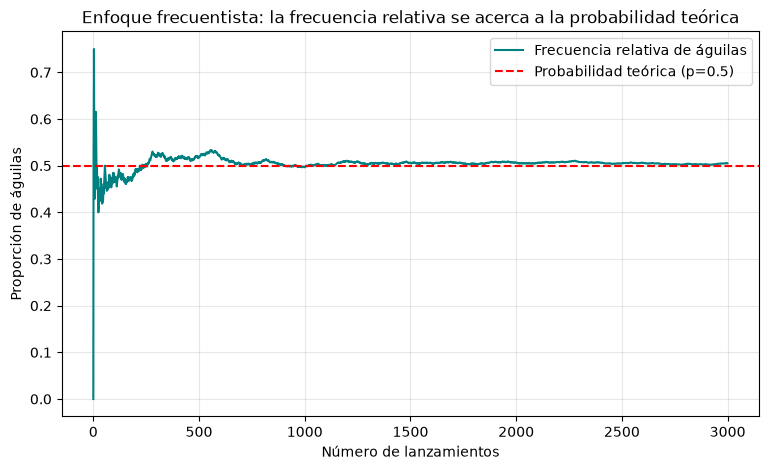

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Fijamos una semilla para poder reproducir los resultados
np.random.seed(42)

n_lanzamientos = 3000
p_verdadera = 0.5

# Simulamos n_lanzamientos volados: 1 = águila, 0 = sol
volados = np.random.binomial(n=1, p=p_verdadera, size=n_lanzamientos)

# Calculamos la proporción acumulada de águilas después de cada lanzamiento
proporcion_acumulada = np.cumsum(volados) / np.arange(1, n_lanzamientos + 1)

print("Proporción de águilas tras", n_lanzamientos, "lanzamientos:", proporcion_acumulada[-1])

# Graficamos cómo se acerca la frecuencia relativa a la probabilidad teórica
plt.figure(figsize=(9, 5))
plt.plot(proporcion_acumulada, color='teal', label='Frecuencia relativa de águilas')
plt.axhline(p_verdadera, color='red', linestyle='--', label='Probabilidad teórica (p=0.5)')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Proporción de águilas')
plt.title('Enfoque frecuentista: la frecuencia relativa se acerca a la probabilidad teórica')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Se nota bien en la gráfica: al principio, con pocos lanzamientos, la proporción de águilas anda saltando y se puede alejar harto de 0.5, nada más por azar. Pero según van pasando más lanzamientos la curva se va calmando y se pega cada vez más a 0.5. Justo esa es la idea de fondo del enfoque frecuentista: entre más repites el experimento, más se parece lo observado a lo teórico.



## 9. Enfoque geométrico: problema del encuentro

El **enfoque geométrico** se usa cuando el espacio muestral no es un conjunto finito de resultados, sino una región continua (un intervalo, un área, un volumen). En este caso, la probabilidad de un evento se calcula como:

$$\mathbb{P}(A) = \frac{\text{área (o longitud, o volumen) favorable}}{\text{área (o longitud, o volumen) total}}.$$

**Ejemplo clásico: el problema del encuentro.** Dos personas, digamos A y B, acuerdan verse en un lugar entre las 12:00 y la 1:00 pm (una hora, es decir 60 minutos). Cada una llega en un instante aleatorio dentro de ese rango, y **están dispuestas a esperar 10 minutos** a la otra persona antes de irse. ¿Cuál es la probabilidad de que en efecto se encuentren?

Si $X$ y $Y$ son los minutos (después de las 12:00) en que llegan A y B respectivamente, con $X,Y\sim \text{Unif}(0,60)$, el evento de interés es:

$$\text{Encuentro} = \{(x,y) \in [0,60]\times[0,60] : |x-y| \leq 10\}.$$

Como $(X,Y)$ se distribuye uniformemente en el cuadrado $[0,60]\times[0,60]$, la probabilidad es el área de la franja donde $|x-y|\le 10$ entre el área total del cuadrado ($60\times 60=3600$). Calculando el área de los dos triángulos que quedan fuera de la franja:

$$\mathbb{P}(\text{Encuentro}) = 1 - \frac{(60-10)^2}{60^2} = 1 - \frac{2500}{3600} = \frac{1100}{3600} = \frac{11}{36} \approx 0.3056.$$

Vamos a verificarlo con una simulación en Python.


Probabilidad teórica  (enfoque geométrico): 0.3056
Probabilidad simulada ( 5000 repeticiones): 0.3102


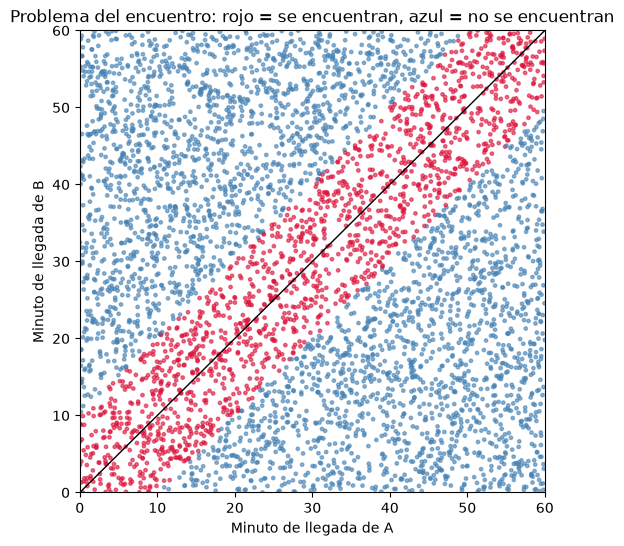

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

n_simulaciones = 5000
T = 60      # rango de llegada: [0,60] minutos
espera = 10  # minutos que cada persona está dispuesta a esperar

# Generamos los tiempos de llegada de A y B, uniformes en [0, T]
X = np.random.uniform(0, T, n_simulaciones)
Y = np.random.uniform(0, T, n_simulaciones)

# El evento "se encuentran" ocurre si la diferencia de tiempos es a lo más 10 minutos
se_encuentran = np.abs(X - Y) <= espera

prob_simulada = np.mean(se_encuentran)
prob_teorica = 1 - ((T - espera) / T) ** 2

print("Probabilidad teórica  (enfoque geométrico):", round(prob_teorica, 4))
print("Probabilidad simulada (", n_simulaciones, "repeticiones):", round(prob_simulada, 4))

# Graficamos: puntos rojos = se encuentran, puntos azules = no se encuentran
colores = np.where(se_encuentran, 'crimson', 'steelblue')

plt.figure(figsize=(6, 6))
plt.scatter(X, Y, c=colores, s=6, alpha=0.6)
plt.plot([0, T], [0, T], color='black', linewidth=1)
plt.xlabel('Minuto de llegada de A')
plt.ylabel('Minuto de llegada de B')
plt.title('Problema del encuentro: rojo = se encuentran, azul = no se encuentran')
plt.xlim(0, T)
plt.ylim(0, T)
plt.show()



En la gráfica se ve cómo la región roja (donde $|X-Y|\le 10$) forma una franja diagonal adentro del cuadrado. Ahí es donde entra el enfoque geométrico: la probabilidad de que se encuentren es nada más qué tanto del cuadrado ocupa esa franja. Y la simulación le atina: ambos números quedan bien cerca de $11/36 \approx 0.3056$, así que el modelo cuadra con lo que pasaría en la vida real.



## 10. Ejemplo adicional propio: el problema del cumpleaños

Como ejemplo adicional, vamos a resolver el famoso **problema del cumpleaños**: en un salón con $n$ personas, ¿cuál es la probabilidad de que **al menos dos** compartan la misma fecha de cumpleaños? (Suponemos 365 días posibles, todos igualmente probables, y que no hay años bisiestos).

**Enfoque clásico.** Es más fácil calcular primero la probabilidad de que **nadie** comparta cumpleaños, y usar el complemento. Si etiquetamos a las personas $1,2,\dots,n$, el número de formas de asignarles cumpleaños sin repetir es $365\times 364\times \cdots \times(365-n+1)$, y el número total de asignaciones posibles es $365^n$. Entonces:

$$\mathbb{P}(\text{nadie comparte}) = \frac{365\cdot 364\cdots(365-n+1)}{365^{n}} \quad \Rightarrow \quad \mathbb{P}(\text{al menos dos comparten}) = 1-\mathbb{P}(\text{nadie comparte}).$$

Vamos a calcular esta probabilidad para $n=23$ personas (el número "famoso" donde la probabilidad ya supera el 50%), y después vamos a **verificarlo con una simulación** (enfoque frecuentista), tal como hicimos en los ejemplos anteriores.


Con 23 personas, P(al menos dos comparten cumpleaños) = 0.5073 (50.73%)
Probabilidad simulada con 20000 repeticiones: 0.5029 (50.29%)


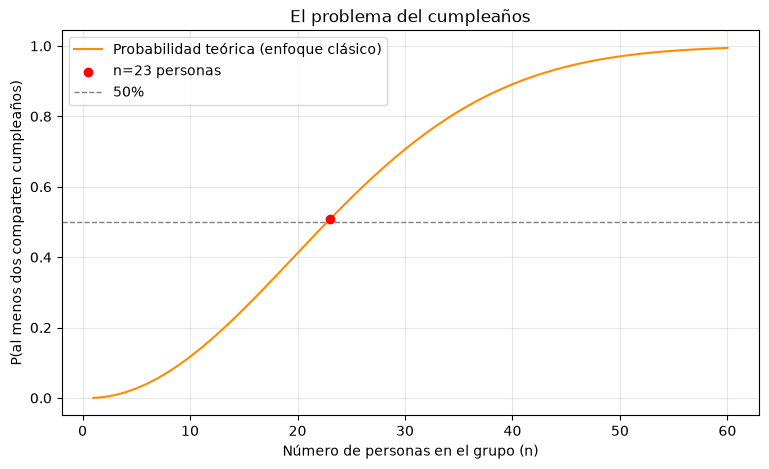

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

def prob_coinciden_clasica(n, dias=365):
    # Calcula, con el enfoque clasico, la probabilidad de que al menos
    # dos personas (de un grupo de n) compartan cumpleanos.
    prob_nadie_comparte = 1.0
    for i in range(n):
        prob_nadie_comparte *= (dias - i) / dias
    return 1 - prob_nadie_comparte

# a) Probabilidad exacta (enfoque clásico) para n = 23
n_personas = 23
prob_23 = prob_coinciden_clasica(n_personas)
print(f"Con {n_personas} personas, P(al menos dos comparten cumpleaños) = {prob_23:.4f} ({prob_23*100:.2f}%)")

# b) Verificación con simulación (enfoque frecuentista)
np.random.seed(0)
n_repeticiones = 20000

def simular_coincidencia(n, dias=365):
    cumpleanos = np.random.randint(0, dias, size=n)
    return len(np.unique(cumpleanos)) < n  # True si hay al menos una coincidencia

coincidencias = [simular_coincidencia(n_personas) for _ in range(n_repeticiones)]
prob_simulada = np.mean(coincidencias)

print(f"Probabilidad simulada con {n_repeticiones} repeticiones: {prob_simulada:.4f} ({prob_simulada*100:.2f}%)")

# c) Graficamos la probabilidad teórica para distintos tamaños de grupo
tamanos = np.arange(1, 61)
probabilidades = [prob_coinciden_clasica(n) for n in tamanos]

plt.figure(figsize=(9, 5))
plt.plot(tamanos, probabilidades, color='darkorange', label='Probabilidad teórica (enfoque clásico)')
plt.scatter([n_personas], [prob_23], color='red', zorder=5, label=f'n={n_personas} personas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50%')
plt.xlabel('Número de personas en el grupo (n)')
plt.ylabel('P(al menos dos comparten cumpleaños)')
plt.title('El problema del cumpleaños')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Este es de los resultados que a todo mundo le sorprenden la primera vez: con nada más 23 personas ya es más probable que sí a que no coincidan dos cumpleaños. Y la simulación le pega prácticamente igual al cálculo exacto, así que confirma que la cuenta está bien hecha. En la gráfica se ve además que con 60 personas la probabilidad ya casi llega a 1, o sea que prácticamente es seguro que hay una coincidencia.



## Conclusión

Haciendo este notebook me quedó más claro que un espacio de probabilidad en realidad son tres piezas trabajando juntas: el espacio muestral (todo lo que puede pasar), los eventos (lo que a mí me interesa que pase) y la probabilidad como tal (qué tan creíble es eso, siempre respetando los axiomas de Kolmogorov, que sin ellos ni siquiera podríamos llamarle "probabilidad" a la función).

Lo que más se me quedó de los ejemplos es que no hay una sola manera de calcular una probabilidad, depende mucho del problema que tengas enfrente. Si los resultados son finitos e igual de posibles, como en un volado o un dado, uso el enfoque clásico y nada más cuento casos favorables entre casos totales. Si en cambio quiero ver qué tanto se acerca lo que observo a lo que dice la teoría (por ejemplo simulando miles de volados en Python), ahí entra el enfoque frecuentista. Y cuando el espacio muestral ya no es un conjunto de resultados contables sino algo continuo, como en el problema del encuentro, la cosa se resuelve comparando áreas con el enfoque geométrico.

También quedó bastante claro para qué sirve la probabilidad condicional (cómo cambia lo que yo creo posible en cuanto sé que algo ya pasó) y la independencia (cuando esa información nueva en realidad no cambia nada, como en el ejemplo del primer dado y la suma 7)
